In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_30963/1361973524.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


In [168]:
k_max = 7

pars = {
    "eta" : 0.9, 
    "beta" : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:3] = 1/3
pars["gamma"][0:3] = 1/3


In [169]:
pars["beta"]

array([0.33333333, 0.33333333, 0.33333333, 0.        , 0.        ,
       0.        , 0.        ])

A components
sparsity = 0.6327, nan = 0.0000
sparsity = 0.9130, nan = 0.0000
sparsity = 0.7347, nan = 0.0000
A
sparsity = 0.9036, nan = 0.0000
B
sparsity = 0.8717, nan = 0.0000


/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:57: RuntimeWarning: invalid value encountered in divide
  print("A components")
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:72: RuntimeWarning: divide by zero encountered in divide
  # need to reshape
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:72: RuntimeWarning: invalid value encountered in divide
  # need to reshape
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:115: RuntimeWarning: divide by zero encountered in divide
  probably wrong in various ways which need to be investigated further and tested
/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:115: RuntimeWarning: invalid value encountered in divide
  probably wrong in various ways which need to be investigated further and tested


[Text(0.5, 1.0, 'Sparsity: 0.992')]

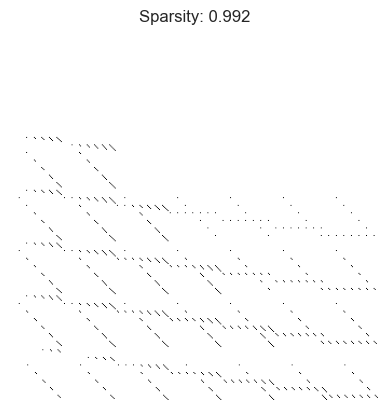

In [256]:
MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

In [257]:
EV = np.linalg.eig(M)

In [258]:
v = np.abs(EV[1][:,0])
T = m.vec_to_tensor(v, k_max)

q = T.sum(axis = (0, 1))
q = q / q.sum()
q

array([0.00000000e+00, 3.62154496e-16, 1.00000000e+00, 1.03981811e-17,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

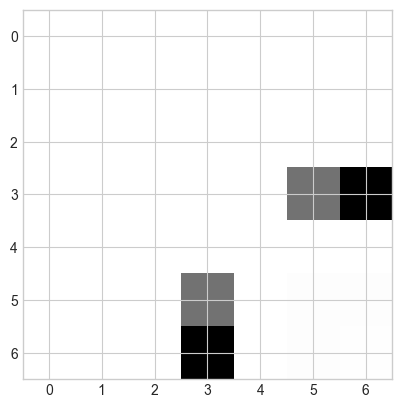

In [272]:
# should be able to get slices of marginal given that intersection of two edges has size k. 
# NOT NECESSARILY SYMMETRIC DUE TO METHOD OF DERIVATION
# we can symmetrize by modifying the derivation. 
# simply adding the array to its transpose should give correct marginals etc. 
# Should have r_{ijk} = 0 when k > i or k > j. 
# We should also have nonzero mass on r_{ij0} for all i, j. 



T = T + np.transpose(T, (1, 0, 2))

k = 3
plt.imshow(T[:,:,k]) # not symmetric, bad. 
# plt.gca().axis("off")

In [263]:

T[:,:,2]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 4.08245172e-01, 2.70571863e-60,
        1.56149393e-03, 3.28647761e-04, 1.70925323e-05],
       [0.00000000e+00, 0.00000000e+00, 8.16490343e-01, 7.11626631e-60,
        3.12298786e-03, 6.57295522e-04, 3.41850647e-05],
       [0.00000000e+00, 0.00000000e+00, 4.08245172e-01, 3.55813315e-60,
        1.56149393e-03, 3.28647761e-04, 1.70925323e-05]])